In [1]:
from dataclasses import dataclass
from enum import StrEnum
from datetime import datetime, timedelta, date
import polars as pl
from collections import defaultdict, Counter
from typing import Tuple
from common.constants.column_types import (
    CPZP_SCHEMA,
    OZP_SCHEMA,
    POHLAVI_CPZP,
    TYP_UDALOSTI,
)
from common.constants.column_names import SHARED_COLUMNS, OZP_COLUMNS, CPZP_COLUMNS
import pickle
from common.constants.objects import (
    Person,
    Gender,
    AgeCohort,
    Prescription,
    PrescriptionType,
)
import matplotlib.pyplot as plt
import numpy as np
import os
from common.utils import (
    draw_chart,
    filter_by_date_range,
)

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(60)

from typing import Any
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from scipy.stats import fisher_exact

pl.Config.set_tbl_rows(-1)
import statistics

POJISTOVNA = "cpzp"


def is_injection(form: str) -> bool:
    return form in {"Injekční suspenze", "Injekční/infuzní roztok"}


def collapse_injections(prescriptions):
    """Yield prescriptions but ignore additional injections within 14 days."""
    last_inj_date = date.min
    for pr in prescriptions:
        if is_injection(pr.lekova_forma):
            if abs((last_inj_date - pr.date).days) < 14:
                continue
            last_inj_date = pr.date
        yield pr


In [2]:
if POJISTOVNA == "both_companies":
    with open("./DATACON_data/cpzp_persons.pkl", "rb") as f:
        cpzp_persons: list[Person] = pickle.load(f)
    with open("./DATACON_data/ozp_persons.pkl", "rb") as f:
        ozp_persons: list[Person] = pickle.load(f)
    persons = cpzp_persons + ozp_persons
else:
    with open(f"./DATACON_data/{POJISTOVNA}_persons.pkl", "rb") as f:
        persons: list[Person] = pickle.load(f)

In [3]:
ROZHODNE_DATUM = date(2021, 6, 16)
START_DATE = date(2015, 1, 1)
END_DATE = date(2023, 12, 31)


num_of_persons = 0
num_of_alive_persons = 0
num_of_all_time_insured_persons = 0
num_of_16_to_29_year_old_persons = 0
num_of_vax_persons = 0
num_of_valid_vax_persons = 0
num_of_prescriptions = 0
num_of_valid_prescriptions = 0

vax_num_of_prescriptions_before = 0
vax_num_of_prescriptions_after = 0
novax_num_of_prescriptions_before = 0
novax_num_of_prescriptions_after = 0

vax_num_of_pred_eq_before = 0
vax_num_of_pred_eq_after = 0
novax_num_of_pred_eq_before = 0
novax_num_of_pred_eq_after = 0

vax_num_of_first_prescription_before = 0
vax_num_of_first_prescription_after = 0
novax_num_of_first_prescription_before = 0
novax_num_of_first_prescription_after = 0

num_of_novax_prescriptions = 0
num_of_valid_novax_prescriptions = 0


def find_first_corticoide_prescription(
    prescriptions: list[Prescription],
) -> Prescription | None:
    corticoides = [
        p for p in prescriptions if p.prescription_type == PrescriptionType.KORTIKOID
    ]
    if not corticoides:
        return None
    return min(corticoides, key=lambda p: p.date)


for person in persons:
    num_of_persons += 1
    if not person.died_at:
        num_of_alive_persons += 1
        if (
            person.zahajeni_pojisteni < START_DATE
            and person.ukonceni_pojisteni > END_DATE
        ):
            num_of_all_time_insured_persons += 1

            if person.born_at.year >= 1992 and person.born_at.year <= 2005:
                num_of_16_to_29_year_old_persons += 1

                if person.vaccines:
                    num_of_vax_persons += 1

                    first_dose_vaccine = person.vaccines[0]
                    if first_dose_vaccine.date >= ROZHODNE_DATUM - timedelta(
                        days=14
                    ) and first_dose_vaccine.date <= ROZHODNE_DATUM + timedelta(
                        days=14
                    ):
                        num_of_valid_vax_persons += 1

                        for prescription in collapse_injections(person.prescriptions):
                            if (
                                prescription.prescription_type
                                == PrescriptionType.IMUNOSUPRESSIVE
                            ):
                                continue
                            num_of_prescriptions += 1

                            if (
                                prescription.date
                                >= first_dose_vaccine.date - timedelta(days=365)
                                and prescription.date
                                < first_dose_vaccine.date + timedelta(days=365)
                            ):
                                num_of_valid_prescriptions += 1

                                if prescription.date < first_dose_vaccine.date:
                                    vax_num_of_prescriptions_before += 1
                                    vax_num_of_pred_eq_before += (
                                        prescription.prednison_equiv
                                    )
                                else:
                                    vax_num_of_prescriptions_after += 1
                                    vax_num_of_pred_eq_after += (
                                        prescription.prednison_equiv
                                    )

                        first_corticoide_prescription = (
                            find_first_corticoide_prescription(person.prescriptions)
                        )
                        if first_corticoide_prescription:
                            if (
                                first_corticoide_prescription.date
                                >= first_dose_vaccine.date - timedelta(days=365)
                                and first_corticoide_prescription.date
                                < first_dose_vaccine.date + timedelta(days=365)
                            ):
                                if (
                                    first_corticoide_prescription.date
                                    < first_dose_vaccine.date
                                ):
                                    vax_num_of_first_prescription_before += 1
                                else:
                                    vax_num_of_first_prescription_after += 1

                else:
                    for prescription in collapse_injections(person.prescriptions):
                        if (
                            prescription.prescription_type
                            == PrescriptionType.IMUNOSUPRESSIVE
                        ):
                            continue
                        num_of_novax_prescriptions += 1
                        if prescription.date >= ROZHODNE_DATUM - timedelta(
                            days=365
                        ) and prescription.date < ROZHODNE_DATUM + timedelta(days=365):
                            num_of_valid_novax_prescriptions += 1
                            if prescription.date < ROZHODNE_DATUM:
                                novax_num_of_prescriptions_before += 1
                                novax_num_of_pred_eq_before += (
                                    prescription.prednison_equiv
                                )
                            else:
                                novax_num_of_prescriptions_after += 1
                                novax_num_of_pred_eq_after += (
                                    prescription.prednison_equiv
                                )

                    first_corticoide_prescription = find_first_corticoide_prescription(
                        person.prescriptions
                    )
                    if first_corticoide_prescription:
                        if (
                            first_corticoide_prescription.date
                            >= ROZHODNE_DATUM - timedelta(days=365)
                            and first_corticoide_prescription.date
                            < ROZHODNE_DATUM + timedelta(days=365)
                        ):
                            if first_corticoide_prescription.date < ROZHODNE_DATUM:
                                novax_num_of_first_prescription_before += 1
                            else:
                                novax_num_of_first_prescription_after += 1

print(f"Number of persons: {num_of_persons}")
print(f"Number of alive persons: {num_of_alive_persons}")
print(f"Number of all-time insured persons: {num_of_all_time_insured_persons}")
print(f"Number of 16-29 year old persons: {num_of_16_to_29_year_old_persons}")
print(f"Number of vax persons: {num_of_vax_persons}")
print(f"Number of valid vax persons: {num_of_valid_vax_persons}")
print(f"Number of prescriptions: {num_of_prescriptions}")
print(f"Number of valid prescriptions: {num_of_valid_prescriptions}")

print(f"Number of prescriptions before vax: {vax_num_of_prescriptions_before}")
print(f"Number of prescriptions after vax: {vax_num_of_prescriptions_after}")
print(f"Number of prescriptions before vax: {novax_num_of_prescriptions_before}")
print(f"Number of prescriptions after vax: {novax_num_of_prescriptions_after}")

print(f"Number of prednison equivalents before vax: {vax_num_of_pred_eq_before}")
print(f"Number of prednison equivalents after vax: {vax_num_of_pred_eq_after}")
print(f"Number of prednison equivalents before vax: {novax_num_of_pred_eq_before}")
print(f"Number of prednison equivalents after vax: {novax_num_of_pred_eq_after}")

print(
    f"Number of first prescriptions before vax: {vax_num_of_first_prescription_before}"
)
print(f"Number of first prescriptions after vax: {vax_num_of_first_prescription_after}")
print(
    f"Number of first prescriptions before vax: {novax_num_of_first_prescription_before}"
)
print(
    f"Number of first prescriptions after vax: {novax_num_of_first_prescription_after}"
)

print(f"Number of novax prescriptions: {num_of_novax_prescriptions}")
print(f"Number of valid novax prescriptions: {num_of_valid_novax_prescriptions}")


Number of persons: 1570780
Number of alive persons: 1466955
Number of all-time insured persons: 999162
Number of 16-29 year old persons: 170596
Number of vax persons: 105878
Number of valid vax persons: 34204
Number of prescriptions: 14863
Number of valid prescriptions: 3871
Number of prescriptions before vax: 1765
Number of prescriptions after vax: 2106
Number of prescriptions before vax: 2921
Number of prescriptions after vax: 3495
Number of prednison equivalents before vax: 407087.125
Number of prednison equivalents after vax: 525809.6875
Number of prednison equivalents before vax: 905068.34375
Number of prednison equivalents after vax: 1033480.0
Number of first prescriptions before vax: 716
Number of first prescriptions after vax: 820
Number of first prescriptions before vax: 1110
Number of first prescriptions after vax: 1299
Number of novax prescriptions: 25585
Number of valid novax prescriptions: 6416


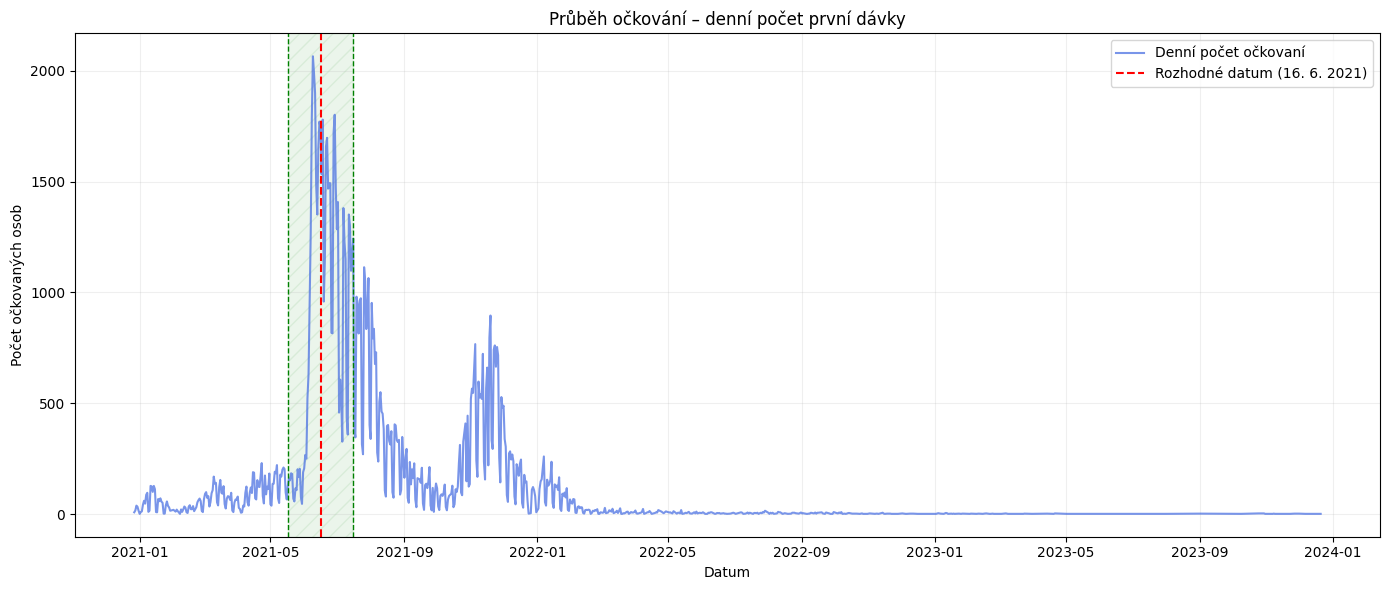

In [15]:
from datetime import date, timedelta
import matplotlib.pyplot as plt
from collections import Counter

# Referenční datum
ROZHODNE_DATUM = date(2021, 6, 16)

# Získání všech dat první dávky
vaccine_dates = [
    p.vaccines[0].date
    for p in persons
    if p.vaccines
    and p.vaccines[0].date is not None
    and p.born_at.year >= 1992
    and p.born_at.year <= 2005
]

if not vaccine_dates:
    print("⚠️  Žádná data o očkování nejsou k dispozici.")
else:
    counts_by_day = Counter(vaccine_dates)
    sorted_dates = sorted(counts_by_day.keys())
    counts = [counts_by_day[d] for d in sorted_dates]

    left = ROZHODNE_DATUM - timedelta(days=30)
    right = ROZHODNE_DATUM + timedelta(days=30)

    # Vykreslení grafu
    plt.figure(figsize=(14, 6))
    plt.plot(
        sorted_dates, counts, label="Denní počet očkovaní", alpha=0.7, color="royalblue"
    )

    plt.axvline(left, color="green", linestyle="--", linewidth=1)
    plt.axvline(right, color="green", linestyle="--", linewidth=1)
    plt.axvspan(
        left, right, facecolor="green", alpha=0.08, hatch="//", edgecolor="green"
    )

    plt.axvline(
        ROZHODNE_DATUM,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Rozhodné datum (16. 6. 2021)",
    )

    plt.title("Průběh očkování – denní počet první dávky")
    plt.xlabel("Datum")
    plt.ylabel("Počet očkovaných osob")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
